In [1]:
# Reinstall scikit-learn and numpy to resolve potential version conflicts
!pip uninstall scikit-learn numpy -y
!pip install scikit-learn numpy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

def get_human_dataset():
    dataset = load_breast_cancer()
    features = dataset.data
    labels = dataset.target

    cancer_df = pd.DataFrame(data=features, columns=dataset.feature_names)
    cancer_df['target'] = labels

    X_features = cancer_df.iloc[:, :-1]
    y_label = cancer_df.iloc[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

    return X_train, X_test, y_train, y_test

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
Found existing installation: numpy 2.4.3
Uninstalling numpy-2.4.3:
  Successfully uninstalled numpy-2.4.3
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompati

In [2]:
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

start_time = time.time()

In [3]:
!pip install xgboost==1.7.1

In [4]:
import xgboost as xgb
from xgboost import XGBClassifier

In [5]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
labels = dataset.target

cancer_df = pd.DataFrame(data=features, columns=dataset.feature_names)
cancer_df['target']= labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [6]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [7]:
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

X_train, X_test, y_train, y_test= train_test_split(X_features, y_label, test_size=0.2)

X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [8]:
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest=xgb.DMatrix(data=X_test, label=y_test)

In [9]:
params = { 'max_depth': 3,
           'eta': 0.05,
           'objective': 'binary:logistic',
           'eval_metric': 'logloss'}

num_rounds = 490

In [10]:
eval_list = [(dval, 'eval')]

xgb_model = xgb.train(params = params, dtrain=dtr, num_boost_round=num_rounds, \
                      early_stopping_rounds=50, evals=eval_list)

[0]	eval-logloss:0.65695
[1]	eval-logloss:0.62215
[2]	eval-logloss:0.59140
[3]	eval-logloss:0.56011
[4]	eval-logloss:0.53148
[5]	eval-logloss:0.50520
[6]	eval-logloss:0.48308
[7]	eval-logloss:0.45996
[8]	eval-logloss:0.43742
[9]	eval-logloss:0.41743
[10]	eval-logloss:0.39832
[11]	eval-logloss:0.38017
[12]	eval-logloss:0.36339
[13]	eval-logloss:0.34720
[14]	eval-logloss:0.33242
[15]	eval-logloss:0.31823
[16]	eval-logloss:0.30519
[17]	eval-logloss:0.29352
[18]	eval-logloss:0.28162
[19]	eval-logloss:0.27095
[20]	eval-logloss:0.26109
[21]	eval-logloss:0.25171
[22]	eval-logloss:0.24245
[23]	eval-logloss:0.23420
[24]	eval-logloss:0.22598
[25]	eval-logloss:0.21916
[26]	eval-logloss:0.21190
[27]	eval-logloss:0.20549
[28]	eval-logloss:0.19880
[29]	eval-logloss:0.19291
[30]	eval-logloss:0.18698
[31]	eval-logloss:0.18234
[32]	eval-logloss:0.17698
[33]	eval-logloss:0.17160
[34]	eval-logloss:0.16571
[35]	eval-logloss:0.16089
[36]	eval-logloss:0.15689
[37]	eval-logloss:0.15405
[38]	eval-logloss:0.15

In [11]:
pred_probs = xgb_model.predict(dtest)
print('predict( ) 수행 결괏값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10], 3))

preds = [1 if x > 0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시:', preds[:10])

predict( ) 수행 결괏값을 10개만 표시, 예측 확률 값으로 표시됨
[0.999 0.    1.    0.999 0.    0.999 1.    0.812 0.335 0.999]
예측값 10개만 표시: [1, 0, 1, 1, 0, 1, 1, 1, 0, 1]


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_clf_eval(y_test, pred, pred_proba):
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, ROC AUC: {roc_auc:.4f}')

get_clf_eval(y_test, preds, pred_probs)

정확도: 0.9649, 정밀도: 1.0000, 재현율: 0.9444, F1: 0.9714, ROC AUC: 0.9967


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

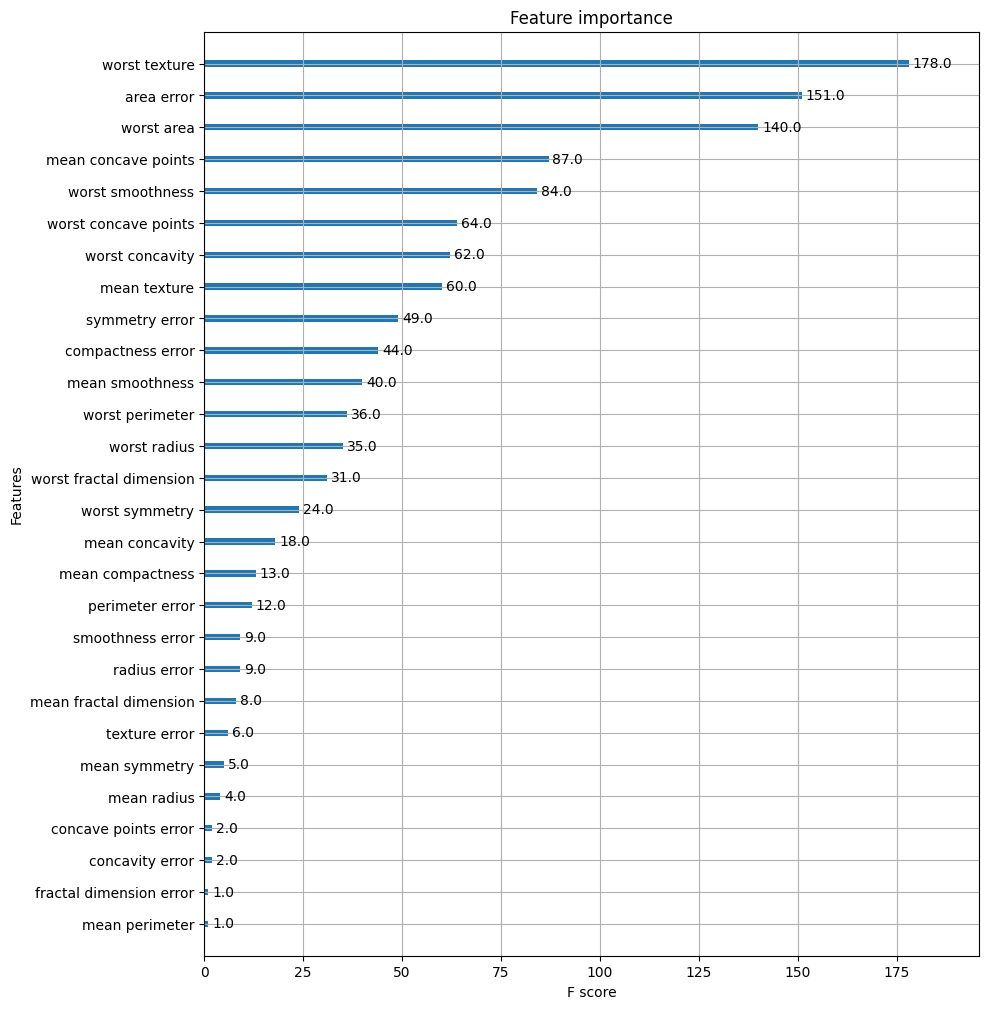

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
plot_importance(xgb_model, ax=ax)

In [14]:
from xgboost import XGBClassifier
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3,
                            eval_metric='logloss')
xgb_wrapper.fit(X_train, y_train, verbose=True)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:,-1]

get_clf_eval(y_test, w_preds, w_pred_proba)

정확도: 0.9737, 정밀도: 1.0000, 재현율: 0.9583, F1: 0.9787, ROC AUC: 0.9980


In [15]:
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3)
evals = [(X_tr, y_tr), (X_val, y_val)]

early_stopping_callback = EarlyStopping(rounds=50, metric_name='logloss', data_name='validation_0')

xgb_wrapper.fit(X_tr, y_tr,
                eval_set=evals,
                callbacks=[early_stopping_callback],
                verbose=True)

ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]

[0]	validation_0-logloss:0.65162	validation_1-logloss:0.65695
[1]	validation_0-logloss:0.61444	validation_1-logloss:0.62215
[2]	validation_0-logloss:0.57994	validation_1-logloss:0.59140
[3]	validation_0-logloss:0.54769	validation_1-logloss:0.56011
[4]	validation_0-logloss:0.51810	validation_1-logloss:0.53148
[5]	validation_0-logloss:0.49087	validation_1-logloss:0.50520
[6]	validation_0-logloss:0.46568	validation_1-logloss:0.48308
[7]	validation_0-logloss:0.44232	validation_1-logloss:0.45996
[8]	validation_0-logloss:0.41993	validation_1-logloss:0.43742
[9]	validation_0-logloss:0.39978	validation_1-logloss:0.41743
[10]	validation_0-logloss:0.38042	validation_1-logloss:0.39832
[11]	validation_0-logloss:0.36213	validation_1-logloss:0.38017
[12]	validation_0-logloss:0.34526	validation_1-logloss:0.36339
[13]	validation_0-logloss:0.32924	validation_1-logloss:0.34720
[14]	validation_0-logloss:0.31426	validation_1-logloss:0.33242
[15]	validation_0-logloss:0.30012	validation_1-logloss:0.31823
[1

In [16]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

정확도: 0.9649, 정밀도: 1.0000, 재현율: 0.9444, F1: 0.9714, ROC AUC: 0.9967


In [17]:
xgb_wrapper.fit(X_tr, y_tr, early_stopping_rounds=10,
                eval_metric="logloss", eval_set=evals, verbose=True)
ws10_preds = xgb_wrapper.predict(X_test)
ws10_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]
get_clf_eval(y_test, ws10_preds, ws10_pred_proba)

[0]	validation_0-logloss:0.65162	validation_1-logloss:0.65695
[1]	validation_0-logloss:0.61444	validation_1-logloss:0.62215
[2]	validation_0-logloss:0.57994	validation_1-logloss:0.59140
[3]	validation_0-logloss:0.54769	validation_1-logloss:0.56011
[4]	validation_0-logloss:0.51810	validation_1-logloss:0.53148
[5]	validation_0-logloss:0.49087	validation_1-logloss:0.50520
[6]	validation_0-logloss:0.46568	validation_1-logloss:0.48308
[7]	validation_0-logloss:0.44232	validation_1-logloss:0.45996
[8]	validation_0-logloss:0.41993	validation_1-logloss:0.43742
[9]	validation_0-logloss:0.39978	validation_1-logloss:0.41743
[10]	validation_0-logloss:0.38042	validation_1-logloss:0.39832
[11]	validation_0-logloss:0.36213	validation_1-logloss:0.38017
[12]	validation_0-logloss:0.34526	validation_1-logloss:0.36339
[13]	validation_0-logloss:0.32924	validation_1-logloss:0.34720
[14]	validation_0-logloss:0.31426	validation_1-logloss:0.33242
[15]	validation_0-logloss:0.30012	validation_1-logloss:0.31823
[1

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

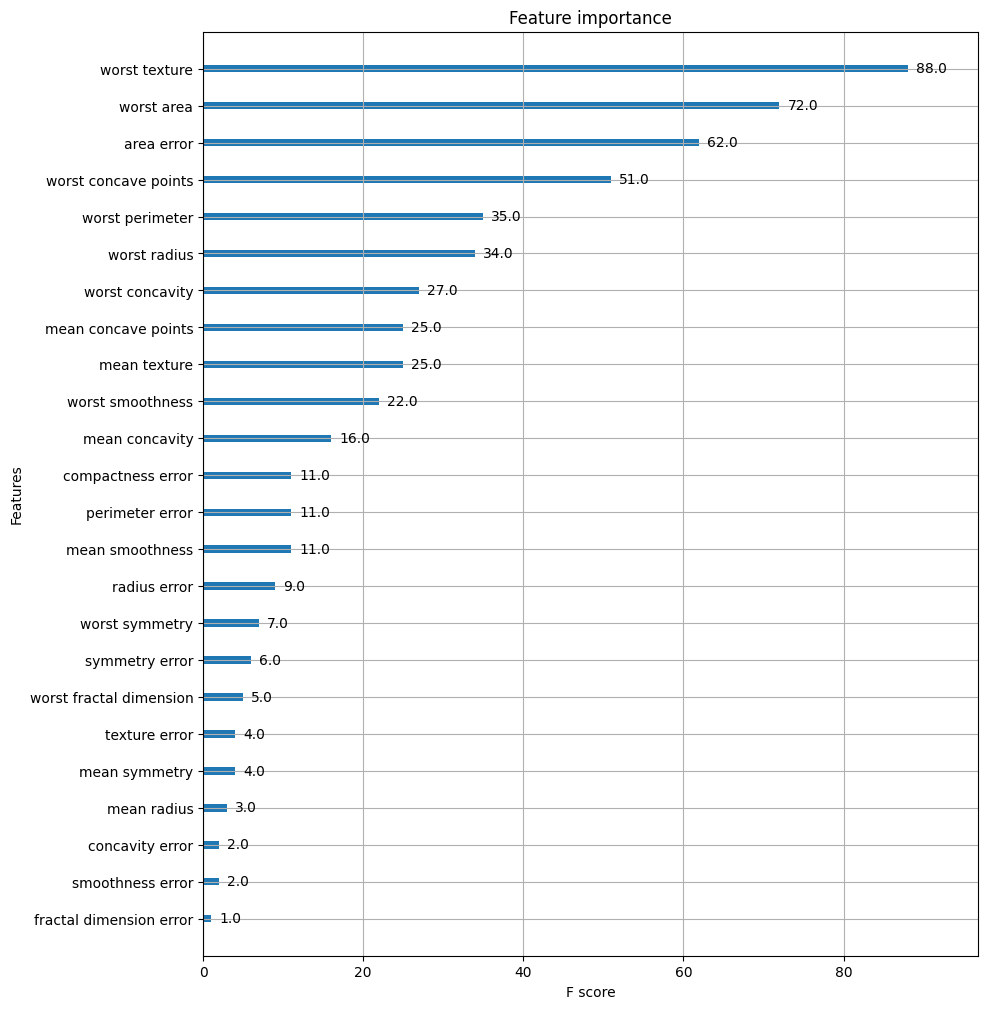

In [18]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax= plt.subplots(figsize=(10,12))
plot_importance(xgb_wrapper, ax=ax)

In [19]:
import lightgbm
from lightgbm import LGBMClassifier

In [20]:
from lightgbm import LGBMClassifier

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)

In [21]:
cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:,-1]

X_train, X_test, y_train, y_test=train_test_split(X_features, y_label, test_size=0.2, random_state=156)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05)

evals = [(X_tr, y_tr), (X_val, y_val)]

# LightGBM에서 early_stopping을 위해 callback 사용
from lightgbm.callback import early_stopping
early_stopping_callback = early_stopping(stopping_rounds=50, verbose=True)

lgbm_wrapper.fit(X_tr, y_tr,
                 eval_set=evals,
                 eval_metric="logloss",
                 callbacks=[early_stopping_callback]) # early_stopping_rounds 대신 callbacks 인자를 사용
preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:,1]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[61]	training's binary_logloss: 0.0532381	valid_1's binary_logloss: 0.260236


In [22]:
get_clf_eval(y_test, preds, pred_proba)

정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740, F1: 0.9677, ROC AUC: 0.9877


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

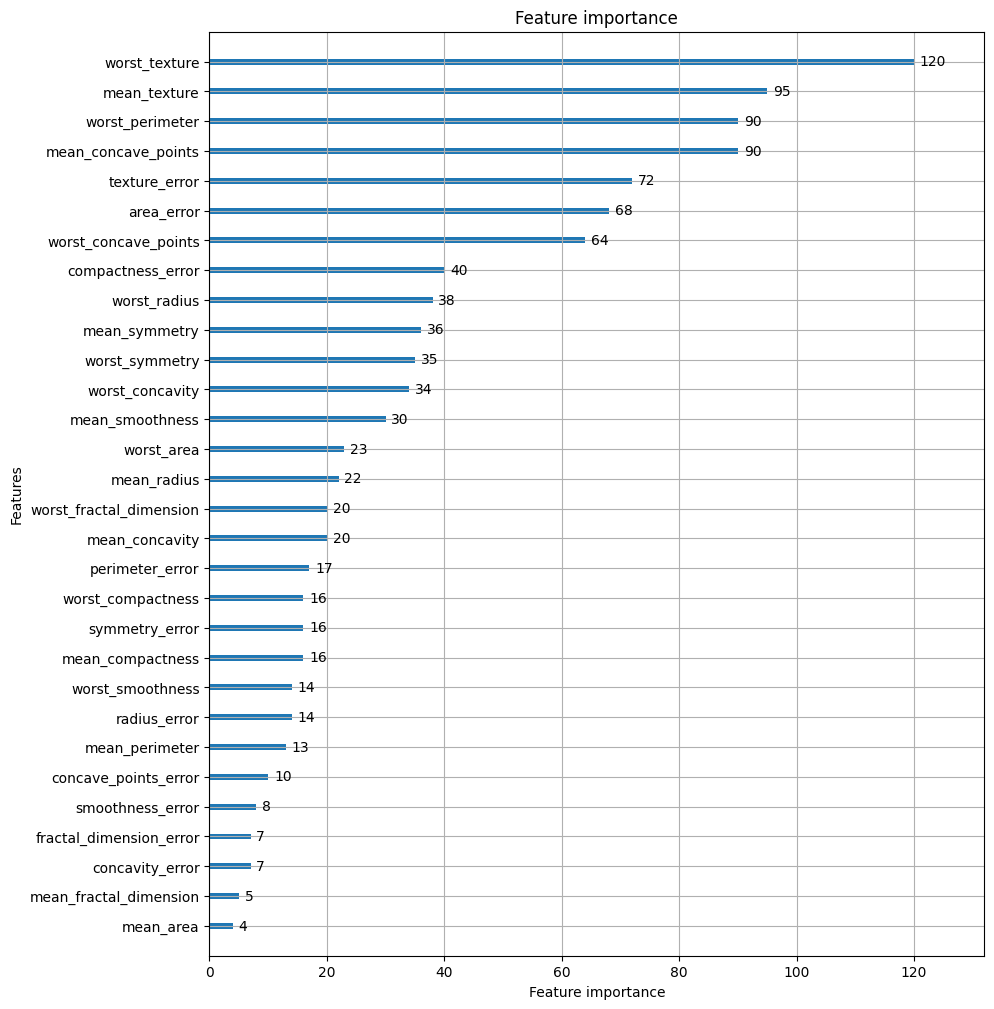

In [23]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(lgbm_wrapper, ax=ax)

In [24]:
params = {
    'max_depth': [10, 20, 30, 40, 50], 'num_leaves': [35, 45, 55, 65],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9], 'subsample' : [0.5, 0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [10, 20, 30, 40], 'reg_alpha': [0.01, 0.05, 0.1]
}

In [25]:
pip install hyperopt

In [26]:
from hyperopt import hp

search_space = {'x': hp.quniform('x', -10, 10, 1), 'y': hp.quniform('y', -15, 15, 1)}

In [27]:
from hyperopt import STATUS_OK

def objective_func(search_space):
  x = search_space['x']
  y = search_space['y']
  retval = x**2 - 20*y

  return retval

In [28]:
from hyperopt import fmin, tpe, Trials
trial_val = Trials()

best_01 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=5,
               trials=trial_val, rstate=np.random.default_rng(seed=0))

print('best:', best_01)

100%|██████████| 5/5 [00:00<00:00, 549.09trial/s, best loss: -224.0]
best: {'x': np.float64(-4.0), 'y': np.float64(12.0)}


In [29]:
trial_val = Trials()

best_02 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=20,
               trials=trial_val, rstate=np.random.default_rng(seed=0))

print('best:', best_02)

100%|██████████| 20/20 [00:00<00:00, 584.12trial/s, best loss: -296.0]
best: {'x': np.float64(2.0), 'y': np.float64(15.0)}


In [30]:
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


In [31]:
print(trial_val.vals)

{'x': [np.float64(-6.0), np.float64(-4.0), np.float64(4.0), np.float64(-4.0), np.float64(9.0), np.float64(2.0), np.float64(10.0), np.float64(-9.0), np.float64(-8.0), np.float64(-0.0), np.float64(-0.0), np.float64(1.0), np.float64(9.0), np.float64(6.0), np.float64(9.0), np.float64(2.0), np.float64(-2.0), np.float64(-4.0), np.float64(7.0), np.float64(-0.0)], 'y': [np.float64(5.0), np.float64(10.0), np.float64(-2.0), np.float64(12.0), np.float64(1.0), np.float64(15.0), np.float64(7.0), np.float64(-10.0), np.float64(0.0), np.float64(-5.0), np.float64(-3.0), np.float64(2.0), np.float64(4.0), np.float64(10.0), np.float64(3.0), np.float64(3.0), np.float64(-14.0), np.float64(-8.0), np.float64(11.0), np.float64(-0.0)]}


In [32]:
import pandas as pd

losses = [loss_dict['loss'] for loss_dict in trial_val.results]

result_df = pd.DataFrame({'x': trial_val.vals['x'], 'y': trial_val.vals['y'], 'losses': losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


In [33]:
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label, test_size=0.2, random_state=156)

In [34]:
X_tr, X_val, y_tr, y_val=train_test_split(X_train, y_train, test_size=0.1, random_state=156)

In [35]:
from hyperopt import hp

xgb_search_space = {'max_depth': hp.quniform('max_depth', 5, 20, 1),
                    'min_child_weight': hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
                    }

In [36]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

def objective_func(search_space):
  xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                          min_child_weight=int(search_space['min_child_weight']),
                          learning_rate=search_space['learning_rate'],
                          colsample_bytree=search_space['colsample_bytree'],
                          eval_metric='logloss')

  accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)

  return {'loss':-1 * np.mean(accuracy), 'status': STATUS_OK}

In [37]:
from hyperopt import fmin, tpe, Trials

trial_val = Trials()
best = fmin(fn=objective_func,
            space=xgb_search_space,
            max_evals=50,
            trials=trial_val, rstate=np.random.default_rng(seed=9))

print('best:', best)

100%|██████████| 50/50 [00:47<00:00,  1.04trial/s, best loss: -0.9648396653886372]
best: {'colsample_bytree': np.float64(0.6367020408228946), 'learning_rate': np.float64(0.17542594661299368), 'max_depth': np.float64(17.0), 'min_child_weight': np.float64(2.0)}


In [38]:
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'], 5), round(best['learning_rate'], 5),
    int(best['max_depth']), int(best['min_child_weight'])))

colsample_bytree:0.6367, learning_rate:0.17543, max_depth:17, min_child_weight:2


In [39]:
xgb_wrapper = XGBClassifier(n_estimators = 400,
                            learning_rate=round(best['learning_rate'], 5),
                            max_depth=int(best['max_depth']),
                            min_child_weight=int(best['min_child_weight']),
                            colsample_bytree=round(best['colsample_bytree'], 5)
                            )
evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, early_stopping_rounds=50, eval_metric='logloss',
                eval_set=evals, verbose=True)
pred=xgb_wrapper.predict(X_test)
pred_proba=xgb_wrapper.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, preds, pred_proba)

[0]	validation_0-logloss:0.55232	validation_1-logloss:0.59166
[1]	validation_0-logloss:0.45267	validation_1-logloss:0.53027
[2]	validation_0-logloss:0.37707	validation_1-logloss:0.47056
[3]	validation_0-logloss:0.31784	validation_1-logloss:0.42540
[4]	validation_0-logloss:0.27052	validation_1-logloss:0.38484
[5]	validation_0-logloss:0.23321	validation_1-logloss:0.35497
[6]	validation_0-logloss:0.20155	validation_1-logloss:0.33684
[7]	validation_0-logloss:0.17642	validation_1-logloss:0.32440
[8]	validation_0-logloss:0.15404	validation_1-logloss:0.31093
[9]	validation_0-logloss:0.13779	validation_1-logloss:0.29666
[10]	validation_0-logloss:0.12276	validation_1-logloss:0.28419
[11]	validation_0-logloss:0.10784	validation_1-logloss:0.26580
[12]	validation_0-logloss:0.09695	validation_1-logloss:0.26392
[13]	validation_0-logloss:0.08880	validation_1-logloss:0.26499
[14]	validation_0-logloss:0.08150	validation_1-logloss:0.26178
[15]	validation_0-logloss:0.07502	validation_1-logloss:0.25834
[1

In [44]:
%pip install imbalanced-learn

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

card_df = pd.read_csv('./creditcard.csv')
card_df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [48]:
from sklearn.model_selection import train_test_split

def get_preprocessed_df(df=None):
  df_copy = df.copy()
  df_copy.drop('Time', axis=1, inplace=True)
  return df_copy

In [50]:
def get_train_test_dataset(df=None):
  df_copy = get_preprocessed_df(df)
  X_features = df_copy.iloc[:, :-1]
  y_target = df_copy.iloc[:, -1]
  X_train, X_test, y_train, y_test = \
  train_test_split(X_features, y_target, test_size=0.3, random_state=0, stratify=y_target)

  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)


In [51]:
print('학습 데이터 레이블 값 비율')
print(y_train.value_counts()/y_train.shape[0] * 100)
print('테스트 데이터 레이블 값 비율')
print(y_test.value_counts()/y_test.shape[0] * 100)

학습 데이터 레이블 값 비율
Class
0    99.827451
1     0.172549
Name: count, dtype: float64
테스트 데이터 레이블 값 비율
Class
0    99.826785
1     0.173215
Name: count, dtype: float64


In [52]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, lr_pred, lr_pred_proba)

정확도: 0.9992, 정밀도: 0.8692, 재현율: 0.6284, F1: 0.7294, ROC AUC: 0.9722


In [70]:
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
  model.fit(ftr_train, tgt_train)
  pred = model.predict(ftr_test)
  pred_proba = model.predict_proba(ftr_test)[:, 1]
  get_clf_eval(tgt_test, pred, pred_proba)

In [89]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

정확도: 0.9995, 정밀도: 0.9569, 재현율: 0.7500, F1: 0.8409, ROC AUC: 0.9779


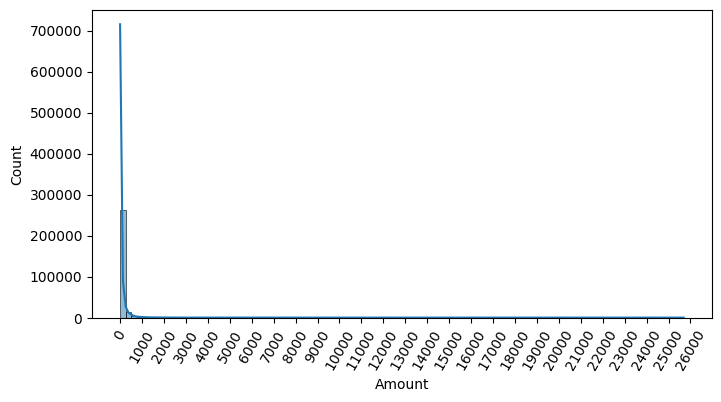

In [91]:
import seaborn as sns

plt.figure(figsize=(8,4))
plt.xticks(range(0, 30000, 1000), rotation=60)
sns.histplot(card_df['Amount'], bins=100, kde=True)
plt.show()

In [55]:
from lightgbm import LGBMModel

lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

정확도: 0.9995, 정밀도: 0.9573, 재현율: 0.7568, F1: 0.8453, ROC AUC: 0.9790


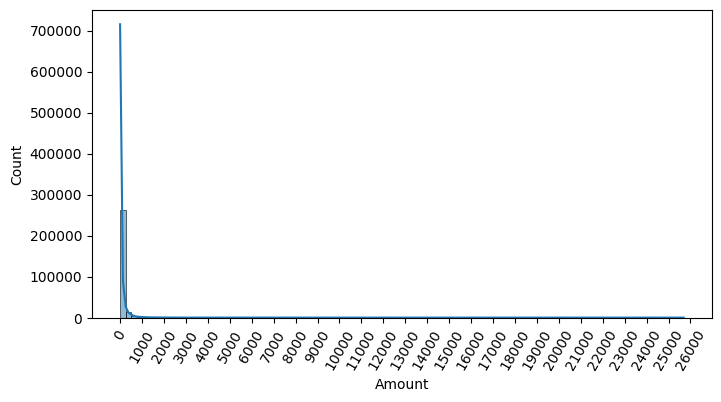

In [65]:
import seaborn as sns

plt.figure(figsize=(8, 4))
plt.xticks(range(0, 30000, 1000), rotation=60)
sns.histplot(card_df['Amount'], bins=100, kde=True)
plt.show()

In [88]:
print('### 로지스틱 회귀 예측 성능 ###')
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
print('### LightGBM 예측 성능 ###')
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
정확도: 0.9992, 정밀도: 0.8692, 재현율: 0.6284, F1: 0.7294, ROC AUC: 0.9706
### LightGBM 예측 성능 ###
정확도: 0.9995, 정밀도: 0.9569, 재현율: 0.7500, F1: 0.8409, ROC AUC: 0.9779


In [66]:
from sklearn.preprocessing import StandardScaler

def get_preprocessed_df(df=None):
  df_copy = df.copy()
  scaler = StandardScaler()
  amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1))
  df_copy.insert(0, 'Amount_Scaled', amount_n)
  df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)

  return df_copy

X_train, X_test, y_train, y_test=get_train_test_dataset(card_df)

In [75]:
print('### 로지스틱 회귀 예측 성능 ###')
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train,
                     tgt_test=y_test)
print('### LightGBM 예측 성능 ###')
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train,
                     tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
정확도: 0.9992, 정밀도: 0.8692, 재현율: 0.6284, F1: 0.7294, ROC AUC: 0.9706
### LightGBM 예측 성능 ###
정확도: 0.9995, 정밀도: 0.9569, 재현율: 0.7500, F1: 0.8409, ROC AUC: 0.9779


In [62]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, lr_pred, lr_pred_proba)

정확도: 0.9992, 정밀도: 0.8692, 재현율: 0.6284, F1: 0.7294, ROC AUC: 0.9706


<Axes: >

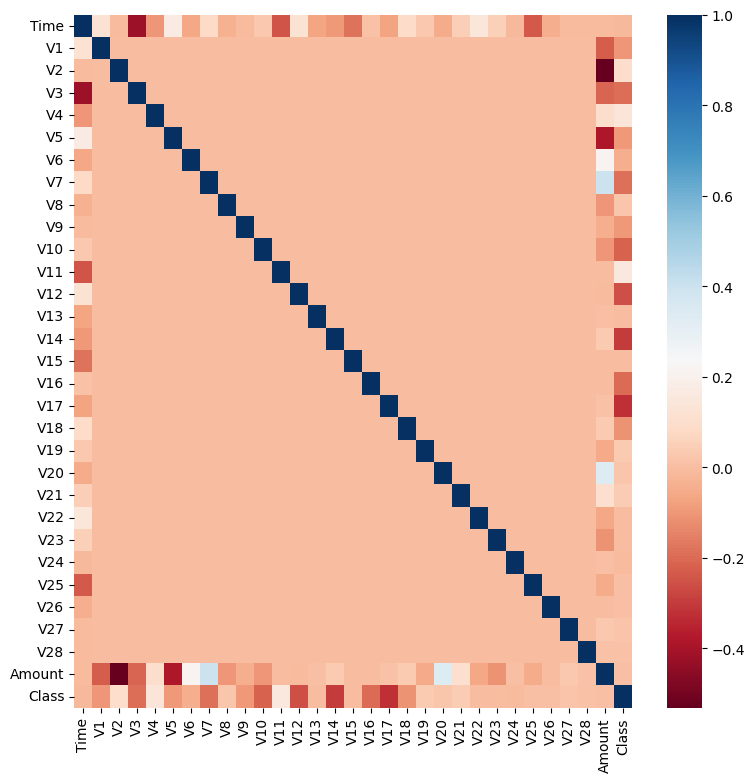

In [77]:
import seaborn as sns

plt.figure(figsize=(9, 9))
corr = card_df.corr()
sns.heatmap(corr, cmap='RdBu')

In [80]:
import numpy as np

def get_outlier(df=None, column=None, weight=1.5):
  fraud = df[df['Class']==1][column]
  quantile_25 = np.percentile(fraud.values, 25)
  quantile_75 = np.percentile(fraud.values, 75)
  iqr = quantile_75 - quantile_25
  iqr_weight = iqr * weight
  lowest_val = quantile_25 - iqr_weight
  highest_val = quantile_75 + iqr_weight

  outlier_index = fraud[(fraud<lowest_val)|(fraud>highest_val)].index

  return outlier_index

In [81]:
outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
print('이상치 데이터 인덱스:', outlier_index)

이상치 데이터 인덱스: Index([8296, 8615, 9035, 9252], dtype='int64')


In [83]:
def get_processed_df(df=None):
  df_copy = df.copy()
  amount_n = np.log1p(df_copy['Amount'])
  df_copy.insert(0, 'Amount_Scaled', 'amount_n')
  df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)

  outlier_index = get_outlier(df=df_copy, column='V14', weight=1.5)
  df_copy.drop(outlier_index, axis=0, inplace=True)

  return df_copy

X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)
print('### 로지스틱 회귀 예측 성능 ###')
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train = y_train,
                     tgt_test=y_test)

print('### LightGBM 예측 성능 ###')
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
정확도: 0.9992, 정밀도: 0.8692, 재현율: 0.6284, F1: 0.7294, ROC AUC: 0.9706
### LightGBM 예측 성능 ###
정확도: 0.9995, 정밀도: 0.9569, 재현율: 0.7500, F1: 0.8409, ROC AUC: 0.9779


In [84]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
print('SMOTE 적용 전 학습용 피처/레이블 데이터 세트: ', X_train.shape, y_train.shape)
print('SMOTE 적용 후 학습용 피처/레이블 데이터 세트: ', X_train_over.shape, y_train_over.shape)
print('SMOTE 적용 후 레이블 값 분포: \n', pd.Series(y_train_over).value_counts())

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x78749cee6a20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


SMOTE 적용 전 학습용 피처/레이블 데이터 세트:  (199364, 29) (199364,)
SMOTE 적용 후 학습용 피처/레이블 데이터 세트:  (398040, 29) (398040,)
SMOTE 적용 후 레이블 값 분포: 
 Class
0    199020
1    199020
Name: count, dtype: int64


In [85]:
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over,
                     tgt_test=y_test)

정확도: 0.9767, 정밀도: 0.0631, 재현율: 0.8986, F1: 0.1180, ROC AUC: 0.9797


In [92]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import numpy as np

def precision_recall_curve_plot(y_test, pred_proba_c1):
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)

    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')

    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlabel('Threshold value')
    plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()

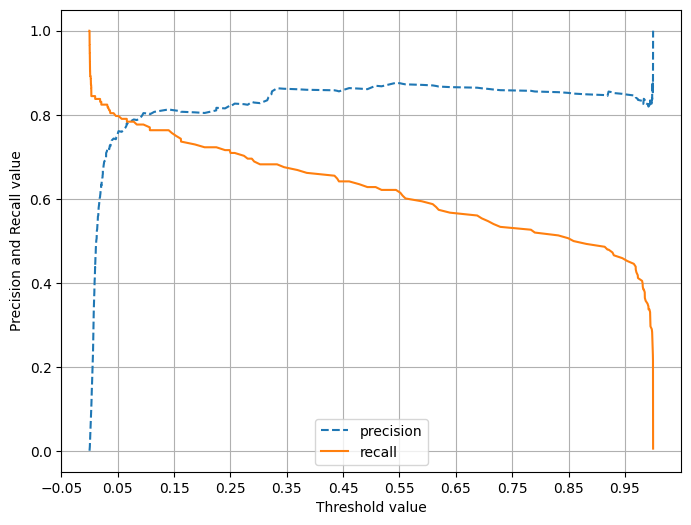

In [93]:
precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])

In [94]:
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train_over, ftr_test=X_test,
                     tgt_train=y_train_over, tgt_test=y_test)

정확도: 0.9995, 정밀도: 0.9134, 재현율: 0.7838, F1: 0.8436, ROC AUC: 0.9761
